In [10]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample
import utils as u

In [11]:
year_list = ["2003"]#,"2004","2005","2006","2007","2008","2009","2010","2011","2012","2013"]
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

In [12]:
# Domain study: Fedchenko, GRf
longitude=slice(66,78)
latitude=slice(36,42)

In [13]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

In [14]:
print('Fedchenko domain')
print('lon min',ds_grF.LON.values.min(),'lon max',ds_grF.LON.values.max())
print('lat min',ds_grF.LAT.values.min(),'lat max',ds_grF.LAT.values.max())

latlim_grF=slice(ds_grF.LAT.values.min(),ds_grF.LAT.values.max())
lonlim_grF=slice(ds_grF.LON.values.min(),ds_grF.LON.values.max())

Fedchenko domain
lon min 67.45302 lon max 77.20667
lat min 36.148087 lat max 41.407486


### MAR

In [15]:
# spin2 available, but annual values only

In [16]:
sourceData='/bettik/amoryc/MARout/GRf/spin3_ICEmask/work/'
variable='TT' ##RF;SF;SHSN3;TT

fileNameF='mon-'+variable+'-MARv3.14_ER5-2003-2013.nc'
dsF= xr.open_dataset(sourceData+fileNameF).isel(ATMLAY=1).TT

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

#MAR reggrided on ERA5-Land grid
dsF_reggrid =  xr.open_dataset('/bettik/fainx/MAR_HMA/reggriding/'+'mon-TT-MARv3.14_ER5-2003-2013_remapped.nc').isel(ATMLAY=1).TT
dsF_reggrid = dsF_reggrid.rename({'TIME': 'time'})

(132, 116, 164)


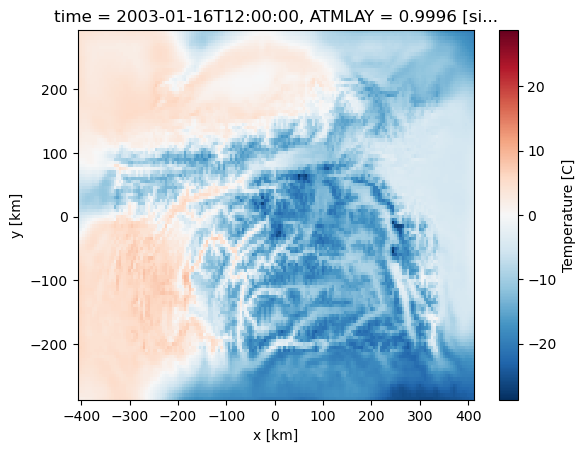

In [17]:
print(dsF_reggrid.shape)
dsF_reggrid[0,:,:].plot()

In [18]:
print(dsF.shape)

(132, 116, 164)


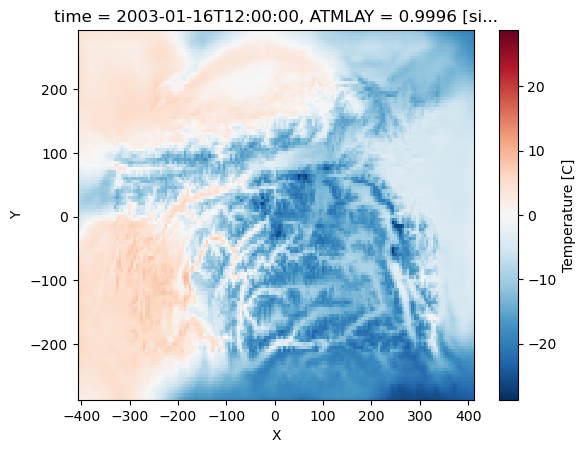

In [19]:
dsF[0,:,:].plot()

### ERA5-land

In [20]:
folder_era5land='/bettik/PROJECTS/pr-regional-climate/observations/ERA5-land/'

tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_GRf.nc').t2m.load()-273.15
tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

#ERA5-Land reggrided on MAR grid
tmp_era5land_reggrid = xr.open_mfdataset(folder_era5land + 'era5_land_GRf_remapped.nc').t2m.load()-273.15

tmp_era5land_reggrid = tmp_era5land_reggrid.rename({'x':'X','y':'Y'})
tmp_era5land_reggrid = tmp_era5land_reggrid.assign_coords(Y=np.round(tmp_era5land_reggrid.Y.values))
tmp_era5land_reggrid = tmp_era5land_reggrid.assign_coords(X=np.round(tmp_era5land_reggrid.X.values))
tmp_era5land_reggrid = tmp_era5land_reggrid.rename({'valid_time': 'time'})

In [21]:
tmp_era5land.shape

(132, 61, 121)

In [22]:
dsF_reggrid.shape

(132, 116, 164)

(132, 61, 121)


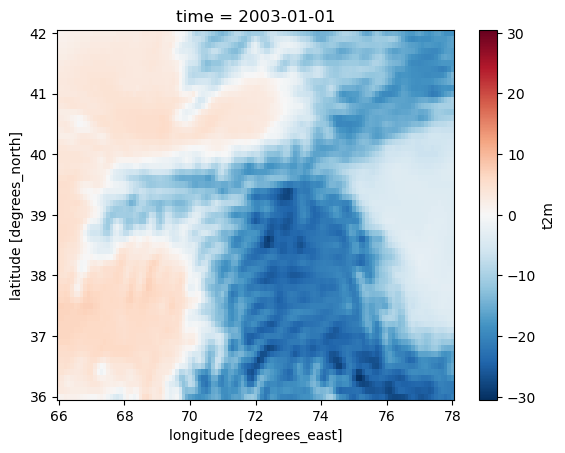

In [23]:
print(tmp_era5land.shape)
tmp_era5land[0,:,:].plot()

(132, 116, 164)


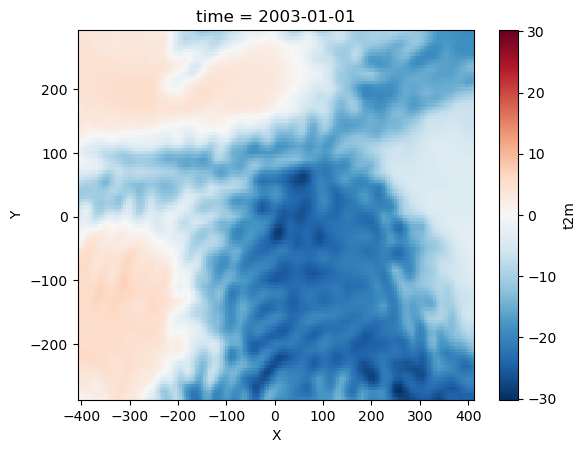

In [24]:
print(tmp_era5land_reggrid.shape)
tmp_era5land_reggrid[0,:,:].plot()

### ERA5

In [25]:
folder_era5='/bettik/PROJECTS/pr-regional-climate/observations/ERA5/'

tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m.nc').t2m.load()-273.15
tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon'})

#ERA5-Land reggrided on MAR grid
tmp_era5_reggrid = xr.open_mfdataset(folder_era5 + 'era5_GRf_t2m_remapped.nc').t2m.load()-273.15

tmp_era5_reggrid = tmp_era5_reggrid.rename({'x':'X','y':'Y'})
tmp_era5_reggrid = tmp_era5_reggrid.assign_coords(Y=np.round(tmp_era5land_reggrid.Y.values))
tmp_era5_reggrid = tmp_era5_reggrid.assign_coords(X=np.round(tmp_era5land_reggrid.X.values))
tmp_era5_reggrid = tmp_era5_reggrid.rename({'valid_time': 'time'})

(1022, 25, 49)


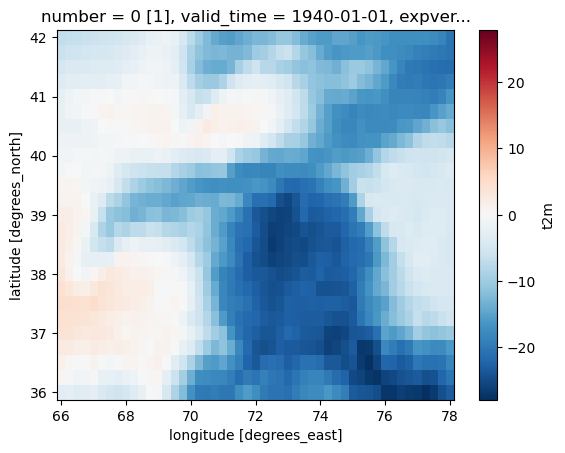

In [26]:
print(tmp_era5.shape)
tmp_era5[0,:,:].plot()

(1022, 116, 164)


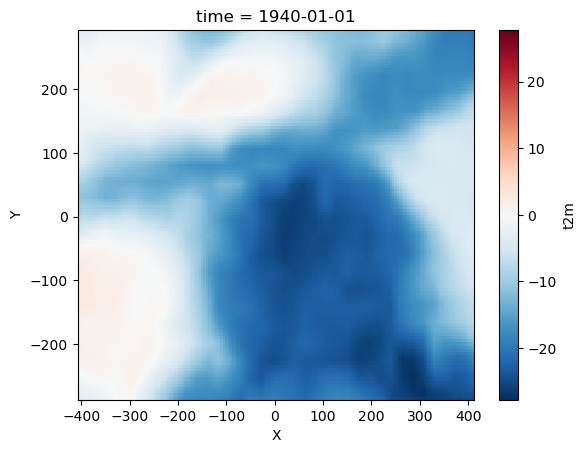

In [27]:
print(tmp_era5_reggrid.shape)
tmp_era5_reggrid[0,:,:].plot()

# Seasonnal differences ERA5-LAND - MAR interpolated on ERA5-Land grid

/tmp/ipykernel_2969004/3082314243.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_grF.LON, ds_grF.LAT,
/tmp/ipykernel_2969004/3082314243.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_reggrid.lon, dsF_reggrid.lat,
/tmp/ipykernel_2969004/3082314243.py:41: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_grF.LO

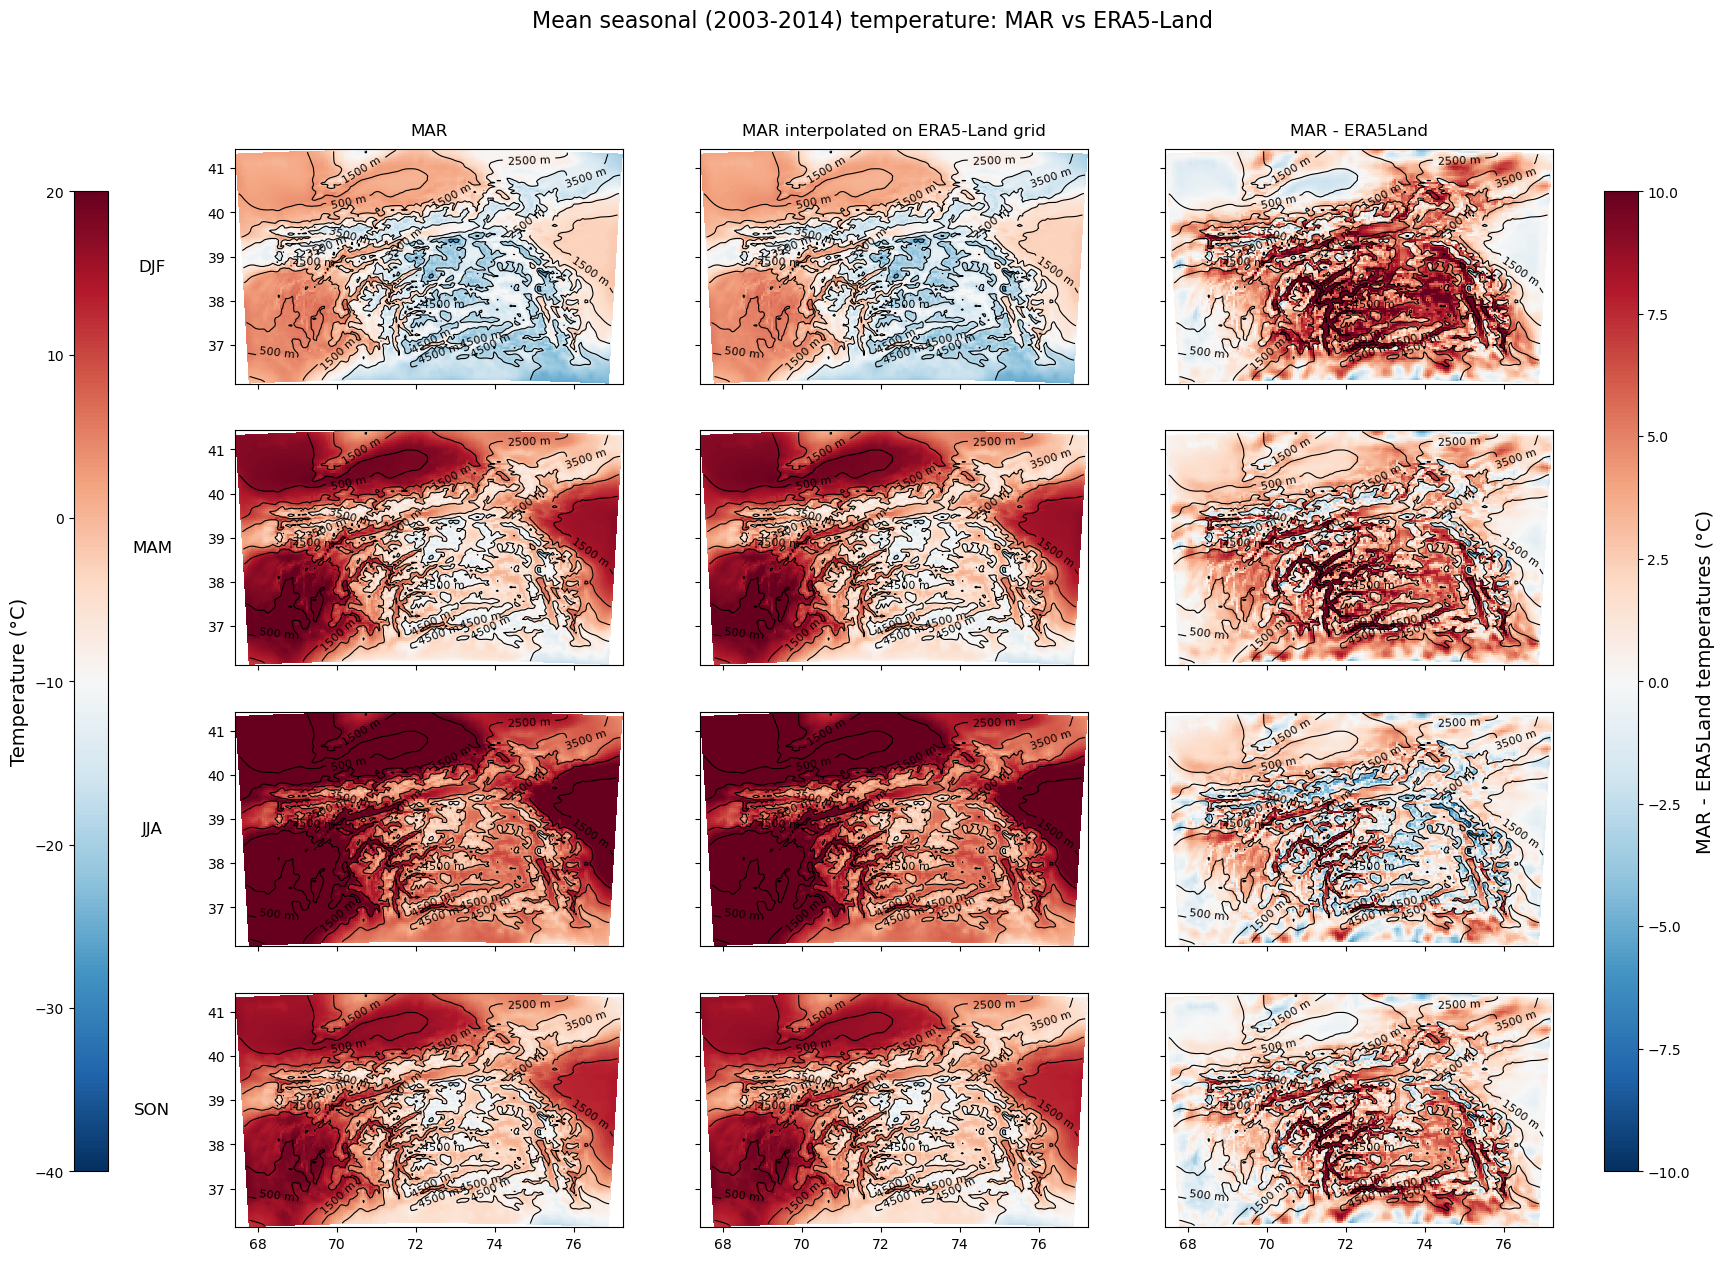

In [32]:
nrows = 4
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR', 'MAR interpolated on ERA5-Land grid', 'MAR - ERA5Land']

diff_meshes = []

# Paramètres communs aux colonnes 1 et 2
temp_cmap = 'RdBu_r'
temp_vmin = -40
temp_vmax = 20

for i, ax in enumerate(axes.flat):
    if (i) % 3 == 0 : 
        m = ax.pcolormesh(ds_grF.LON, ds_grF.LAT,
                          dsF.groupby("time.season").mean('time').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(ds_grF.LON, ds_grF.LAT, ds_grF.SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    
    
    elif (i-1) % 3 == 0 : 
        m = ax.pcolormesh(dsF_reggrid.lon, dsF_reggrid.lat,
                          dsF_reggrid.groupby("time.season").mean('time').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(ds_grF.LON, ds_grF.LAT, ds_grF.SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1


    elif (i - 2) % 3 == 0 : 
        diff = (dsF.groupby('time.season').mean('time').sel(season=season_list[l])
                - tmp_era5land_reggrid.groupby("time.season").mean('time').sel(season=season_list[l]))
        m = ax.pcolormesh(ds_grF.LON, ds_grF.LAT, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(ds_grF.LON, ds_grF.LAT, ds_grF.SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2003-2014) temperature: MAR vs ERA5-Land', fontsize=16)

# Colorbar gauche (colonne 1 et 2)
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite (différences - colonne 3)
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - ERA5Land temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

# plt.savefig("Mar_ERA5land_MARgrid.png", dpi=300, bbox_inches='tight')
plt.show()